## EDA — Credit Card Default Dataset
Exploratory Data Analysis to understand the data before modelling.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)

In [25]:
df = pd.read_excel(r"C:\Jobsties Academy\Updated CV\Data Scientist\DKV Mobility - Machine Learning Engineer - AI Insights (gn)\dkv-ml-casestudy\data\credit_card_default_raw.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [26]:
df.drop(columns=["ID"], inplace=True)

In [27]:
df.rename(columns={"default payment next month": "default"}, inplace=True)

In [28]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [29]:
df.shape

(30000, 24)

### 1. Basic Dataset Info

In [30]:
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  in

In [31]:
# Missing values

print(f"Missing Values: {df.isnull().sum().sum()}")

Missing Values: 0


In [32]:
# Duplicate records

print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 35


In [33]:
df = df.drop_duplicates()
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


In [34]:
df.shape

(29965, 24)

In [35]:
# Statistical Summary

df.describe().round(2)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00
mean,167442.01,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.16,-0.22,-0.26,-0.29,51283.01,49236.37,47067.92,43313.33,40358.33,38917.01,5670.10,5927.98,5231.69,4831.62,4804.90,5221.50,0.22
std,129760.14,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,1.15,73658.13,71195.57,69371.35,64353.51,60817.13,59574.15,16571.85,23053.46,17616.36,15674.46,15286.37,17786.98,0.42
min,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-165580.00,-69777.00,-157264.00,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,3595.00,3010.00,2711.00,2360.00,1787.00,1262.00,1000.00,850.00,390.00,300.00,261.00,131.00,0.00
50%,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,0.00,22438.00,21295.00,20135.00,19081.00,18130.00,17124.00,2102.00,2010.00,1804.00,1500.00,1500.00,1500.00,0.00
75%,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,0.00,67260.00,64109.00,60201.00,54601.00,50247.00,49252.00,5008.00,5000.00,4512.00,4016.00,4042.00,4000.00,0.00
max,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,8.00,964511.00,983931.00,1664089.00,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


### 2. Target Variable — Class Imbalance

In [36]:
# Class distribution

counts = df["default"].value_counts()
pct = df["default"].value_counts(normalize=True) * 100

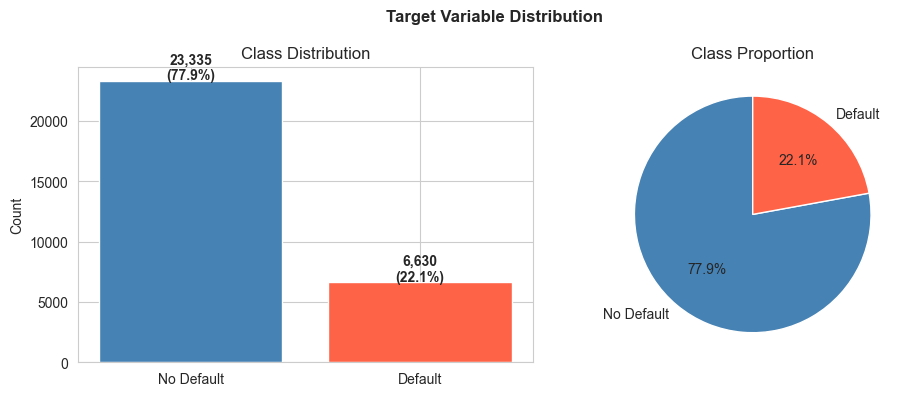

Imbalance ratio: 3.52:1
→ This justifies scale_pos_weight=3.52 in XGBoost
→ And class_weight='balanced' in other models


In [37]:
# Bar chart

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["No Default", "Default"], counts.values,
            color=["steelblue", "tomato"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")

for i, (c, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, c + 100, f"{c:,}\n({p:.1f}%)", ha="center", fontweight="bold")

# Pie chart
axes[1].pie(counts.values,
            labels=["No Default", "Default"],
            colors=["steelblue", "tomato"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Proportion")

plt.suptitle("Target Variable Distribution", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Imbalance ratio: {counts[0]/counts[1]:.2f}:1")
print("→ This justifies scale_pos_weight=3.52 in XGBoost")
print("→ And class_weight='balanced' in other models")

### 3. Demographic Features

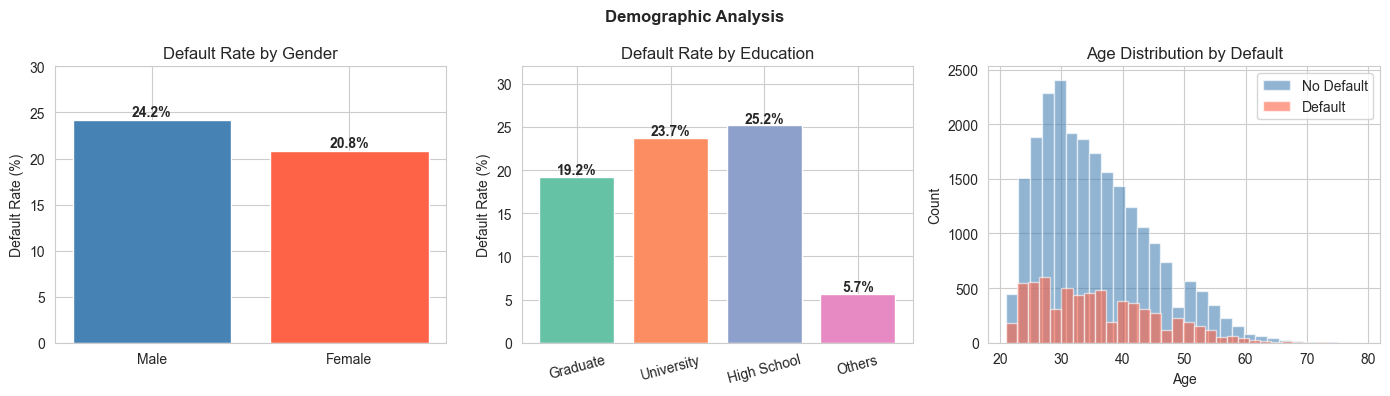

Key observations:
→ Males default more (24.2%) than females (20.8%)
→ High school clients have highest default rate (25.2%)
→ Graduate school clients default least (19.2%)


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Default rate by Gender
sex_default = df.groupby("SEX")["default"].mean() * 100
axes[0].bar(["Male", "Female"], sex_default.values, color=["steelblue", "tomato"])
axes[0].set_title("Default Rate by Gender")
axes[0].set_ylabel("Default Rate (%)")
axes[0].set_ylim(0, 30)
for i, v in enumerate(sex_default.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

# Default rate by Education
edu_map     = {1:"Graduate", 2:"University", 3:"High School", 4:"Others"}
df_edu      = df[df["EDUCATION"].isin([1,2,3,4])].copy()
df_edu["EDUCATION_label"] = df_edu["EDUCATION"].map(edu_map)
edu_default = df_edu.groupby("EDUCATION_label")["default"].mean() * 100
edu_default = edu_default.reindex(["Graduate","University","High School","Others"])
axes[1].bar(edu_default.index, edu_default.values,
            color=sns.color_palette("Set2", 4))
axes[1].set_title("Default Rate by Education")
axes[1].set_ylabel("Default Rate (%)")
axes[1].set_ylim(0, 32)
for i, v in enumerate(edu_default.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")
axes[1].tick_params(axis="x", rotation=15)

# Age distribution
axes[2].hist(df[df["default"]==0]["AGE"], bins=30, alpha=0.6,
             label="No Default", color="steelblue")
axes[2].hist(df[df["default"]==1]["AGE"], bins=30, alpha=0.6,
             label="Default", color="tomato")
axes[2].set_title("Age Distribution by Default")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.suptitle("Demographic Analysis", fontweight="bold")
plt.tight_layout()
plt.show()

print("Key observations:")
print("→ Males default more (24.2%) than females (20.8%)")
print("→ High school clients have highest default rate (25.2%)")
print("→ Graduate school clients default least (19.2%)")

### 4. Credit Limit Analysis

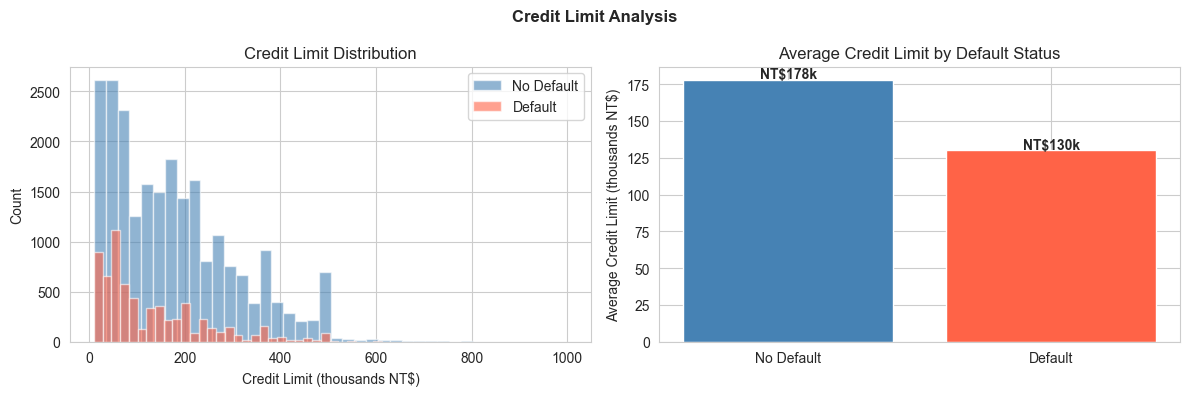

→ Non-defaulters have significantly higher credit limits
→ Higher credit limit = more creditworthy = lower default risk


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Credit limit distribution by default
axes[0].hist(df[df["default"]==0]["LIMIT_BAL"]/1000, bins=40,
             alpha=0.6, label="No Default", color="steelblue")
axes[0].hist(df[df["default"]==1]["LIMIT_BAL"]/1000, bins=40,
             alpha=0.6, label="Default", color="tomato")
axes[0].set_title("Credit Limit Distribution")
axes[0].set_xlabel("Credit Limit (thousands NT$)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Average credit limit by default
avg_limit = df.groupby("default")["LIMIT_BAL"].mean() / 1000
axes[1].bar(["No Default", "Default"], avg_limit.values,
            color=["steelblue", "tomato"])
axes[1].set_title("Average Credit Limit by Default Status")
axes[1].set_ylabel("Average Credit Limit (thousands NT$)")
for i, v in enumerate(avg_limit.values):
    axes[1].text(i, v + 1, f"NT${v:,.0f}k", ha="center", fontweight="bold")

plt.suptitle("Credit Limit Analysis", fontweight="bold")
plt.tight_layout()
plt.show()

print("→ Non-defaulters have significantly higher credit limits")
print("→ Higher credit limit = more creditworthy = lower default risk")

### 5. Payment History Analysis
Most important feature group — how clients repaid over 6 months.

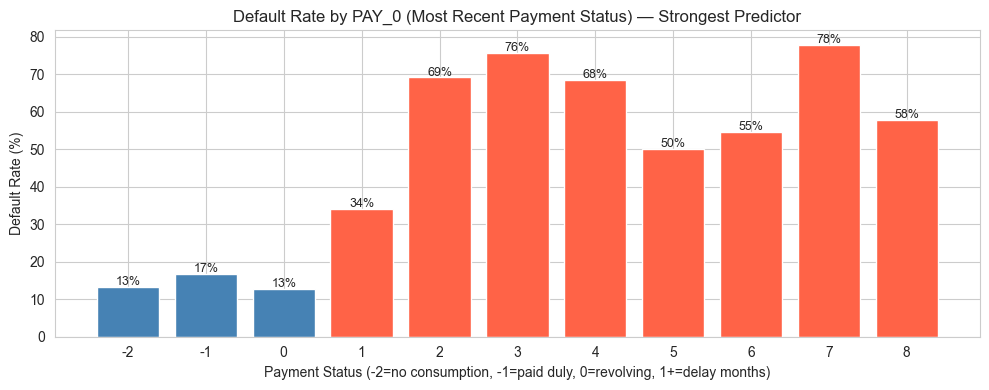

PAY_0 correlation with default: 0.325 — highest of all features
→ Payment delay is the strongest signal of future default


In [40]:
# Payment History

pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
months   = ["Sep","Aug","Jul","Jun","May","Apr"]

# Default rate by PAY_0 (most recent and most important)
pay0_default = df.groupby("PAY_0")["default"].mean() * 100

plt.figure(figsize=(10, 4))
colors = ["tomato" if x > 0 else "steelblue" for x in pay0_default.index]
plt.bar(pay0_default.index.astype(str), pay0_default.values, color=colors)
plt.title("Default Rate by PAY_0 (Most Recent Payment Status) — Strongest Predictor")
plt.xlabel("Payment Status (-2=no consumption, -1=paid duly, 0=revolving, 1+=delay months)")
plt.ylabel("Default Rate (%)")
for i, v in enumerate(pay0_default.values):
    plt.text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("PAY_0 correlation with default: 0.325 — highest of all features")
print("→ Payment delay is the strongest signal of future default")

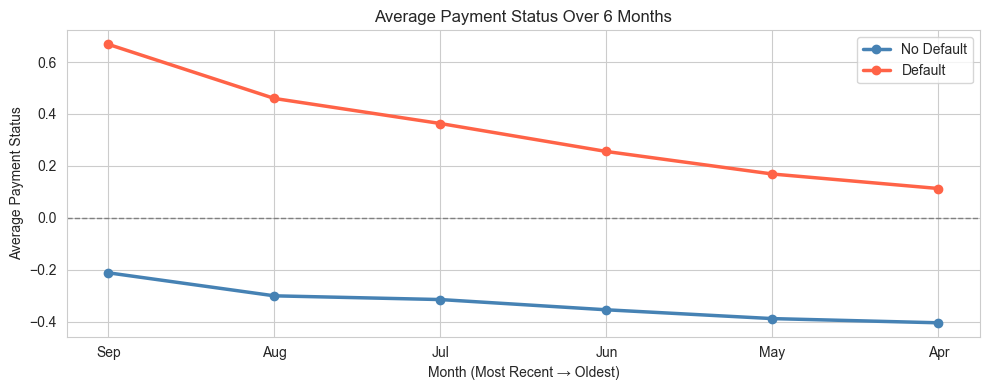

→ Defaulters consistently have higher (worse) payment status scores
→ Pattern persists across all 6 months — not a one-time event


In [41]:
# Payment Delay Trend

# Average payment status over 6 months
avg_pay_default    = df[df["default"]==1][pay_cols].mean()
avg_pay_no_default = df[df["default"]==0][pay_cols].mean()

plt.figure(figsize=(10, 4))
plt.plot(months, avg_pay_no_default.values, marker="o",
         label="No Default", color="steelblue", linewidth=2.5)
plt.plot(months, avg_pay_default.values, marker="o",
         label="Default", color="tomato", linewidth=2.5)
plt.title("Average Payment Status Over 6 Months")
plt.xlabel("Month (Most Recent → Oldest)")
plt.ylabel("Average Payment Status")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

print("→ Defaulters consistently have higher (worse) payment status scores")
print("→ Pattern persists across all 6 months — not a one-time event")

### 6. Bill Amount vs Payment Amount

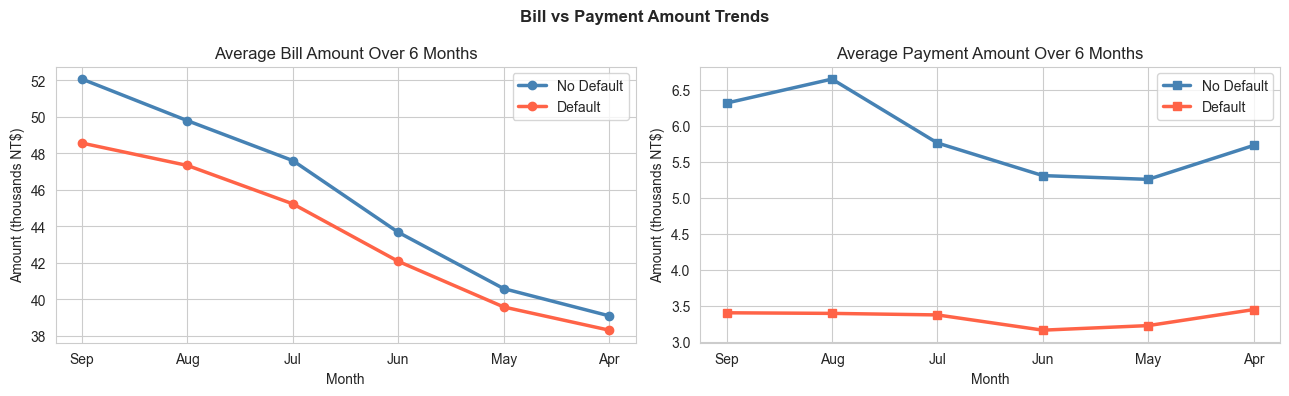

→ Bill amounts are similar between defaulters and non-defaulters
→ But defaulters pay much LESS each month
→ This justifies engineering 'payment_ratio' = avg_pay / avg_bill


In [42]:
bill_cols    = ["BILL_AMT1","BILL_AMT2","BILL_AMT3",
                "BILL_AMT4","BILL_AMT5","BILL_AMT6"]
pay_amt_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3",
                "PAY_AMT4","PAY_AMT5","PAY_AMT6"]

bill_by_default   = df.groupby("default")[bill_cols].mean() / 1000
payamt_by_default = df.groupby("default")[pay_amt_cols].mean() / 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bill amounts
axes[0].plot(months, bill_by_default.loc[0].values,
             marker="o", label="No Default", color="steelblue", linewidth=2.5)
axes[0].plot(months, bill_by_default.loc[1].values,
             marker="o", label="Default", color="tomato", linewidth=2.5)
axes[0].set_title("Average Bill Amount Over 6 Months")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Amount (thousands NT$)")
axes[0].legend()

# Payment amounts
axes[1].plot(months, payamt_by_default.loc[0].values,
             marker="s", label="No Default", color="steelblue", linewidth=2.5)
axes[1].plot(months, payamt_by_default.loc[1].values,
             marker="s", label="Default", color="tomato", linewidth=2.5)
axes[1].set_title("Average Payment Amount Over 6 Months")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Amount (thousands NT$)")
axes[1].legend()

plt.suptitle("Bill vs Payment Amount Trends", fontweight="bold")
plt.tight_layout()
plt.show()

print("→ Bill amounts are similar between defaulters and non-defaulters")
print("→ But defaulters pay much LESS each month")
print("→ This justifies engineering 'payment_ratio' = avg_pay / avg_bill")

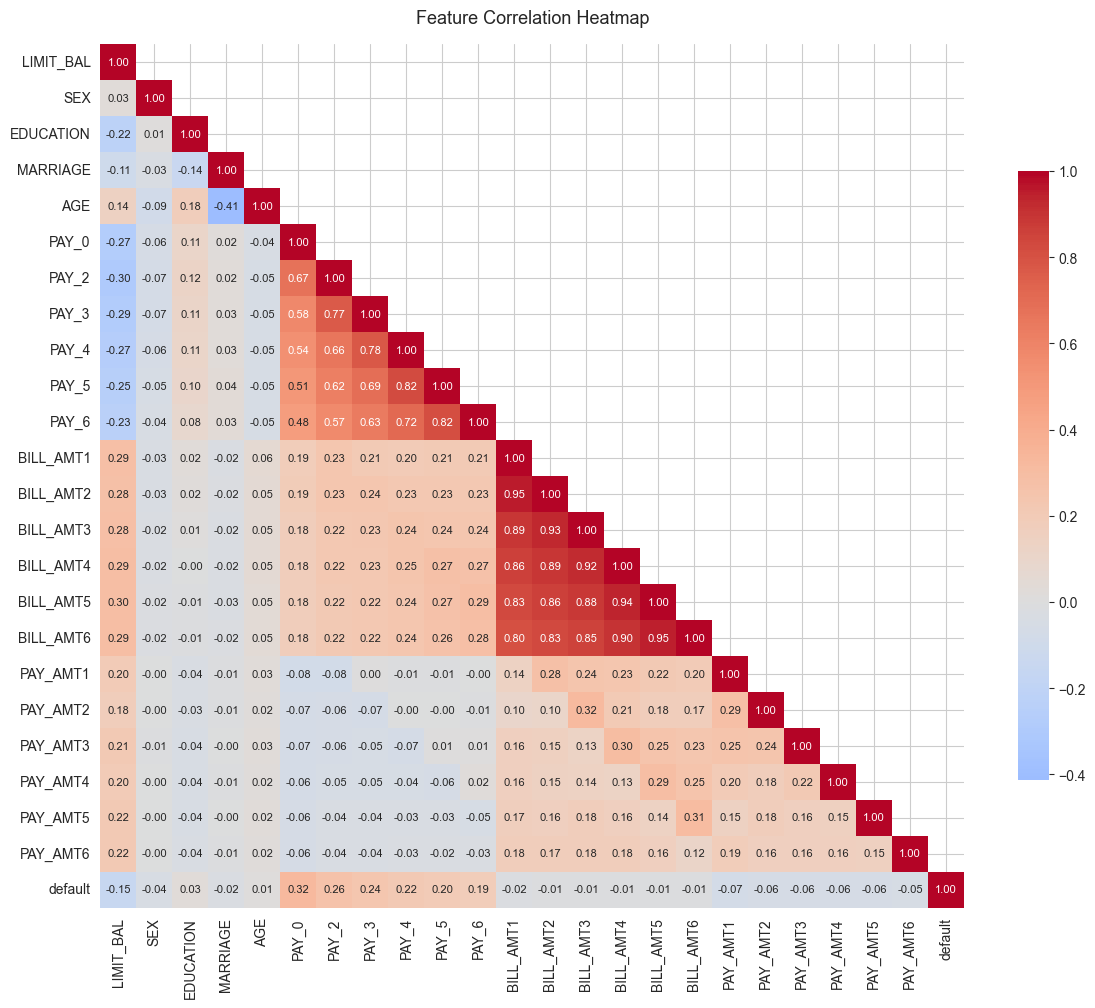

→ BILL_AMT1–BILL_AMT6 correlate at ~0.95 — strong multicollinearity.
This justifies collapsing them into avg_bill_amt as an engineered feature.


In [43]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.7}, annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print("→ BILL_AMT1–BILL_AMT6 correlate at ~0.95 — strong multicollinearity.")
print("This justifies collapsing them into avg_bill_amt as an engineered feature.")

### 7. Correlation with Target

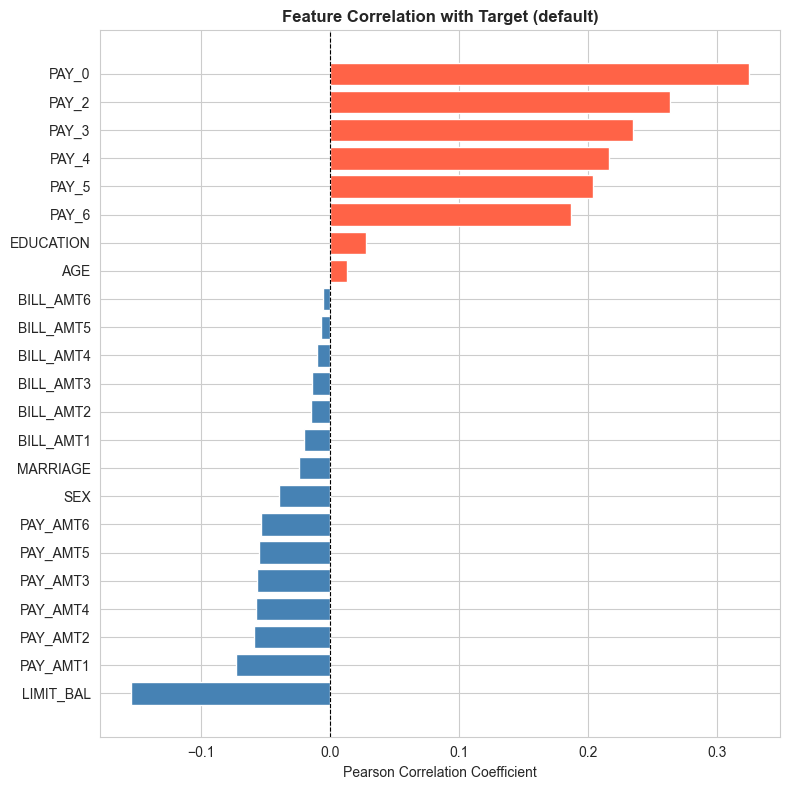

Top 5 positive correlations:
PAY_0    0.324964
PAY_2    0.263656
PAY_3    0.235230
PAY_4    0.216551
PAY_5    0.204059

Top 5 negative correlations:
LIMIT_BAL   -0.153871
PAY_AMT1    -0.073015
PAY_AMT2    -0.058643
PAY_AMT4    -0.056898
PAY_AMT3    -0.056319


In [44]:
# Correlation of all features with target
target_corr = df.corr()["default"].drop("default").sort_values()

plt.figure(figsize=(8, 8))
colors = ["tomato" if v > 0 else "steelblue" for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Feature Correlation with Target (default)", fontweight="bold")
plt.xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.show()

print("Top 5 positive correlations:")
print(target_corr.sort_values(ascending=False).head(5).to_string())
print()
print("Top 5 negative correlations:")
print(target_corr.sort_values().head(5).to_string())

### 8. Undocumented Categories - Data Quality

In [45]:
# Check undocumented categories
print("EDUCATION value counts:")
print(df["EDUCATION"].value_counts().sort_index())
print()
print("→ Values 0, 5, 6 are undocumented in the dataset description")
print("→ These were remapped to 4 (Others) in preprocess.py")
print()

print("MARRIAGE value counts:")
print(df["MARRIAGE"].value_counts().sort_index())
print()
print("→ Value 0 is undocumented")
print("→ Remapped to 3 (Others) in preprocess.py")

EDUCATION value counts:
EDUCATION
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51
Name: count, dtype: int64

→ Values 0, 5, 6 are undocumented in the dataset description
→ These were remapped to 4 (Others) in preprocess.py

MARRIAGE value counts:
MARRIAGE
0       54
1    13643
2    15945
3      323
Name: count, dtype: int64

→ Value 0 is undocumented
→ Remapped to 3 (Others) in preprocess.py


### 9. Summary of Key Findings

In [46]:
print("=" * 55)
print("KEY FINDINGS")
print("=" * 55)
print("""
1. CLASS IMBALANCE
   22.1% default rate — 3.52:1 ratio
   → Used scale_pos_weight=3.52 and class_weight='balanced'

2. MOST IMPORTANT FEATURES
   PAY_0 to PAY_6 (payment history) — highest correlations
   → Payment delays are the strongest signal of default

3. CREDIT LIMIT
   Non-defaulters have higher limits (NT$175k vs NT$130k)
   → Lower limit = higher default risk

4. DEMOGRAPHICS
   Males default more than females (24.2% vs 20.8%)
   High school < University < Graduate school default rates

5. BILL vs PAYMENT
   Similar bill amounts but defaulters pay much less
   → Justifies engineering payment_ratio feature

6. DATA QUALITY
   Zero missing values
   Undocumented categories in EDUCATION (0,5,6) and MARRIAGE (0)
   → Remapped to 'Others' in preprocessing

7. ENGINEERED FEATURES (all add predictive signal)
   avg_bill_amt     — average spending over 6 months
   avg_pay_amt      — average payment over 6 months
   total_delay      — total months of payment delay
   utilisation_ratio — bill / credit limit
   payment_ratio    — payment / bill amount
""")
print("=" * 55)

KEY FINDINGS

1. CLASS IMBALANCE
   22.1% default rate — 3.52:1 ratio
   → Used scale_pos_weight=3.52 and class_weight='balanced'

2. MOST IMPORTANT FEATURES
   PAY_0 to PAY_6 (payment history) — highest correlations
   → Payment delays are the strongest signal of default

3. CREDIT LIMIT
   Non-defaulters have higher limits (NT$175k vs NT$130k)
   → Lower limit = higher default risk

4. DEMOGRAPHICS
   Males default more than females (24.2% vs 20.8%)
   High school < University < Graduate school default rates

5. BILL vs PAYMENT
   Similar bill amounts but defaulters pay much less
   → Justifies engineering payment_ratio feature

6. DATA QUALITY
   Zero missing values
   Undocumented categories in EDUCATION (0,5,6) and MARRIAGE (0)
   → Remapped to 'Others' in preprocessing

7. ENGINEERED FEATURES (all add predictive signal)
   avg_bill_amt     — average spending over 6 months
   avg_pay_amt      — average payment over 6 months
   total_delay      — total months of payment delay
   ut